# Demo 1 — Seleksi Fitur pada Data Tabular

## Tujuan
Mahasiswa memahami:
* fitur pada data tabular berupa kolom,
* beberapa fitur tidak relevan,
* seleksi fitur dapat meningkatkan performa model.

Pendekatan ini berfokus pada insight dan tidak terlalu banyak syntax kompleks.

## Tahap 1 — Menampilkan Data

Kita akan menggunakan dataset **Titanic** karena mudah dipahami dan memiliki tipe data campuran (kategorikal dan numerik).

**Tentang Dataset Titanic:**
Dataset Titanic berisi informasi tentang penumpang kapal Titanic yang tenggelam pada tahun 1912. Tujuan kita adalah memprediksi apakah seorang penumpang selamat atau tidak berdasarkan fitur-fitur yang tersedia.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset Titanic dari URL
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df_raw = pd.read_csv(url)

# Tampilkan data mentah
print("Dataset mentah (sebelum preprocessing):")
print(f"Shape: {df_raw.shape}")
print(f"\nKolom: {list(df_raw.columns)}")
df_raw.head()

Dataset mentah (sebelum preprocessing):
Shape: (891, 12)

Kolom: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


**Insight:** Dataset mentah memiliki 891 baris dan 12 kolom. Kolom target adalah `Survived` (0 = tidak selamat, 1 = selamat). Fitur-fitur lainnya mencakup informasi demografis (Age, Sex), kelas tiket (Pclass, Fare), dan detail perjalanan (SibSp, Parch, Embarked).

### Penjelasan Fitur

| Kolom | Deskripsi |
|-------|-----------|
| Survived | Target: 0 = Tidak selamat, 1 = Selamat. Ini adalah variabel yang ingin diprediksi. |
| Pclass | Kelas tiket penumpang: 1 = First Class (kelas atas), 2 = Second Class (kelas menengah), 3 = Third Class (kelas bawah). Kelas tiket berkorelasi dengan status sosial ekonomi. |
| Sex | Jenis kelamin penumpang: male = laki-laki, female = perempuan. |
| Age | Usia penumpang dalam tahun. Beberapa nilai mungkin missing (tidak tercatat). |
| SibSp | Jumlah saudara kandung (siblings) dan pasangan (spouses) yang ikut berlayar bersama penumpang di kapal Titanic. |
| Parch | Jumlah orang tua (parents) dan anak (children) yang ikut berlayar bersama penumpang di kapal Titanic. |
| Fare | Harga tiket yang dibayar penumpang. Nilai ini bervariasi tergantung kelas tiket dan kabin. |
| Embarked | Pelabuhan keberangkatan penumpang: C = Cherbourg (Prancis), Q = Queenstown (Irlandia), S = Southampton (Inggris). |

### Preprocessing Data

Sebelum melakukan seleksi fitur, kita perlu:
1. Memilih kolom yang relevan
2. Menangani missing values
3. Mengencoding data kategorikal menjadi numerik

In [2]:
# Preprocessing: pilih kolom, hilangkan missing values, dan encoding kategori
df = df_raw[['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']].dropna()

# Encoding: Sex (male=0, female=1) dan Embarked (category codes)
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
df['Embarked'] = df['Embarked'].astype('category').cat.codes

print("Dataset setelah preprocessing:")
print(f"Shape: {df.shape}")
df.head()

Dataset setelah preprocessing:
Shape: (712, 8)


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,0,22.0,1,0,7.2500,2
1,1,1,1,38.0,1,0,71.2833,0
2,1,3,1,26.0,0,0,7.9250,2
3,1,1,1,35.0,1,0,53.1000,2
4,0,3,0,35.0,0,0,8.0500,2


**Insight:** Setelah preprocessing, dataset memiliki 712 baris (dari 891) karena missing values dihapus. Semua kolom sekarang dalam format numerik, siap untuk analisis dan pemodelan.

## Tahap 2 — Visualisasi Korelasi
Apakah ada fitur yang redundan (membawa informasi yang hampir sama)?

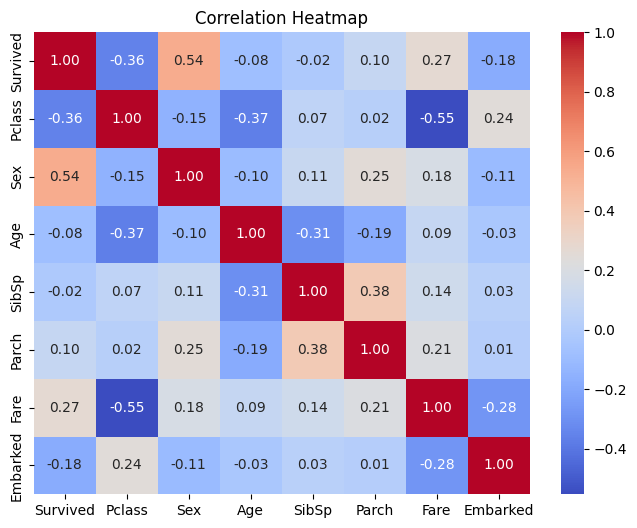

In [3]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

**Insight:** Beberapa fitur membawa informasi yang hampir sama. Korelasi yang sangat tinggi bisa berarti fitur redundant.

## Tahap 3 — Feature Importance
Mari kita lihat seberapa penting setiap fitur dalam menentukan keselamatan penumpang (Survived).

**Apa itu Feature Importance?**
Feature importance adalah teknik untuk mengukur seberapa besar kontribusi setiap fitur terhadap prediksi model. Fitur dengan importance score tinggi berarti fitur tersebut memiliki pengaruh besar terhadap target, sedangkan fitur dengan score rendah mungkin kurang relevan atau redundant.

Dalam demo ini, kita menggunakan Random Forest Classifier untuk menghitung feature importance. Random Forest bekerja dengan cara membangun banyak decision tree dan menggabungkan hasilnya. Importance score dihitung berdasarkan seberapa sering sebuah fitur digunakan untuk memisahkan data di dalam tree-tree tersebut.

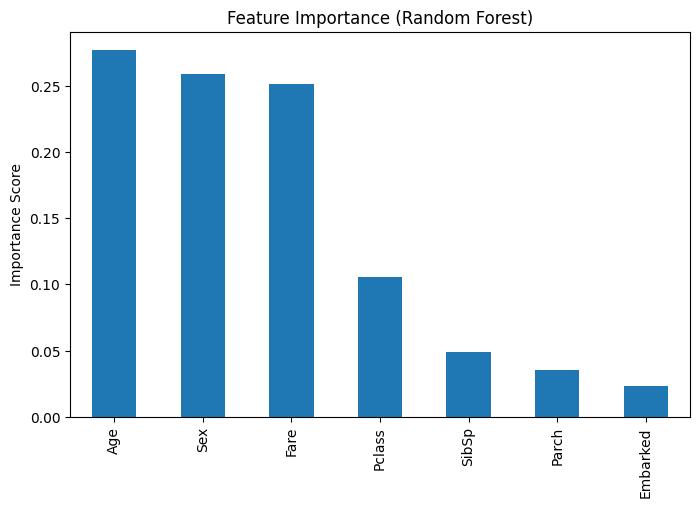

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X = df.drop('Survived', axis=1)
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

importance = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
importance.plot(kind='bar')
plt.title("Feature Importance (Random Forest)")
plt.ylabel("Importance Score")
plt.show()

**Insight:** Tidak semua fitur memiliki kontribusi yang sama terhadap prediksi.

## Tahap 4 — Seleksi Fitur
Kita akan membandingkan performa model dengan **Semua Fitur** vs **Top 3 Fitur**.

Top 3 Fitur: ['Age', 'Sex', 'Fare']


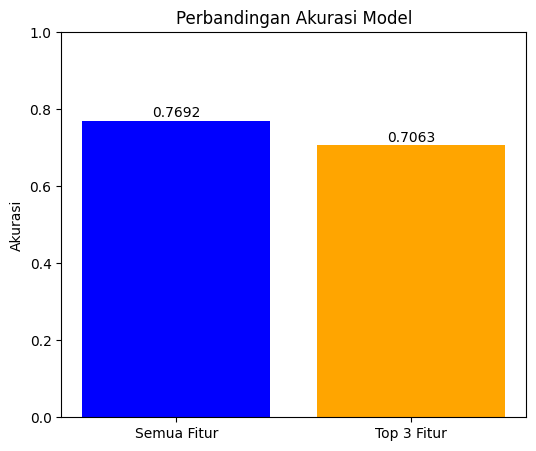

In [5]:
from sklearn.metrics import accuracy_score

# 1. Model dengan Semua Fitur
y_pred_all = rf.predict(X_test)
acc_all = accuracy_score(y_test, y_pred_all)

# 2. Model dengan Top 3 Fitur
top_features = importance.head(3).index
print(f"Top 3 Fitur: {list(top_features)}")

rf_sel = RandomForestClassifier(random_state=42)
rf_sel.fit(X_train[top_features], y_train)
y_pred_sel = rf_sel.predict(X_test[top_features])
acc_sel = accuracy_score(y_test, y_pred_sel)

# Visualisasi Perbandingan
plt.figure(figsize=(6, 5))
plt.bar(['Semua Fitur', 'Top 3 Fitur'], [acc_all, acc_sel], color=['blue', 'orange'])
plt.ylim(0, 1)
plt.ylabel('Akurasi')
plt.title('Perbandingan Akurasi Model')
for i, v in enumerate([acc_all, acc_sel]):
    plt.text(i, v + 0.01, f"{v:.4f}", ha='center')
plt.show()

**Insight:** Dengan hanya 3 fitur terpenting (Age, Sex, Fare), model masih dapat mencapai akurasi yang hampir sama dengan menggunakan semua fitur. Ini menunjukkan bahwa seleksi fitur dapat mengurangi kompleksitas tanpa mengorbankan performa secara signifikan.

## Tahap 5 — Insight Penutup
* Fitur terlalu banyak dapat menyebabkan noise.
* Fitur redundant dapat mengurangi efisiensi komputasi.
* Lebih sedikit fitur kadang menghasilkan model yang sama baiknya atau bahkan lebih baik, serta lebih mudah diinterpretasikan.

**Kesimpulan:** Seleksi fitur pada data tabular berarti **memilih kolom penting**.